In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import yfinance as yf
import random

In [2]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        ticker = yf.Ticker(share_symbol)
        hist = ticker.history(start=start_date, end=end_date)
        stock_prices = hist['Open'].values
        np.save(cache_filename, stock_prices)
    return stock_prices

In [3]:
prices = get_prices('AAPL', '2015-01-01', '2026-01-01', 'aapl_prices.npy')
print(f'Total de días cargados: {len(prices)}')
print(f'Precio mínimo: ${prices.min():.2f}   Precio máximo: ${prices.max():.2f}')

Total de días cargados: 2766
Precio mínimo: $20.51   Precio máximo: $285.93


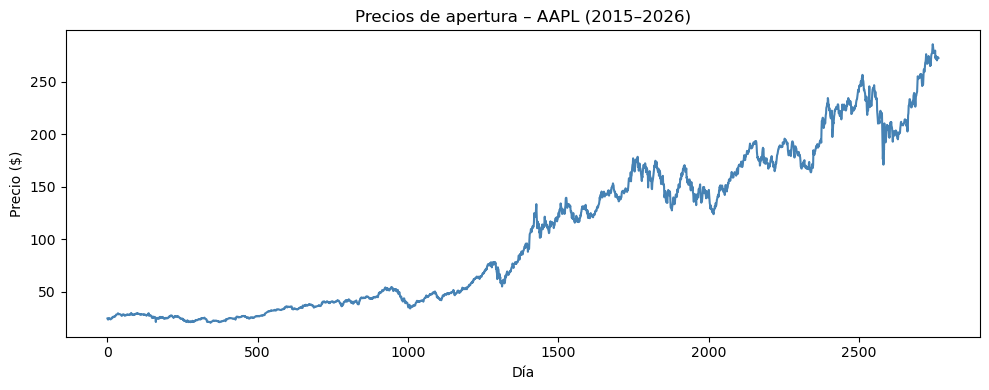

In [4]:
def plot_prices(prices):
    plt.figure(figsize=(10, 4))
    plt.title('Precios de apertura – AAPL (2015–2026)')
    plt.xlabel('Día')
    plt.ylabel('Precio ($)')
    plt.plot(prices, color='steelblue')
    plt.tight_layout()
    plt.savefig('prices_aapl.png')
    plt.show()

plot_prices(prices)

In [5]:
class DecisionPolicy:
    def select_action(self, current_state, step):
        pass
    
    def update_q(self, state, action, reward, next_state):
        pass


class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions
    
    def select_action(self, current_state, step):
        # Ignora el estado, elige al azar
        return random.choice(self.actions)

In [6]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist):
    budget = initial_budget
    num_stocks = initial_num_stocks
    share_value = 0
    
    for i in range(len(prices) - hist - 1):
        current_state = np.asmatrix(np.hstack((prices[i:i+hist], budget, num_stocks)))
        current_portfolio = budget + num_stocks * share_value
        
        action = policy.select_action(current_state, i)
        share_value = float(prices[i + hist + 1])
        
        if action == 'Buy' and budget >= share_value:
            budget -= share_value
            num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
        else:
            action = 'Hold'
        
        new_portfolio = budget + num_stocks * share_value
        reward = new_portfolio - current_portfolio
        next_state = np.asmatrix(np.hstack((prices[i+1:i+hist+1], budget, num_stocks)))

        if i % 50 == 0:
            policy.update_q(current_state, action, reward, next_state)
    
    return budget + num_stocks * share_value

In [7]:
def run_simulations(policy, budget, num_stocks, prices, hist, num_tries=50):
    results = []
    for i in range(num_tries):
        if i % 10 == 0:
            print(f'Progreso: {i}/{num_tries}')
        portfolio = run_simulation(policy, budget, num_stocks, prices, hist)
        results.append(portfolio)
    return np.mean(results), np.std(results)

In [8]:
actions = ['Buy', 'Sell', 'Hold']
hist = 10
budget = 1000.0
num_stocks = 0

random_policy = RandomDecisionPolicy(actions)
avg, std = run_simulations(random_policy, budget, num_stocks, prices, hist)
print(f'\nPolítica aleatoria:')
print(f'  Promedio final del portafolio: ${avg:.2f}')
print(f'  Desviación estándar:           ${std:.2f}')

Progreso: 0/50
Progreso: 10/50
Progreso: 20/50
Progreso: 30/50
Progreso: 40/50

Política aleatoria:
  Promedio final del portafolio: $3515.76
  Desviación estándar:           $1426.36


In [9]:
class QLearningDecisionPolicy(DecisionPolicy):
    def __init__(self, actions, input_dim):
        self.epsilon = 0.9
        self.gamma = 0.001
        self.actions = actions
        output_dim = len(actions)
        hidden_dim = 128

        self.model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_dim,)),
            tf.keras.layers.Dense(hidden_dim, activation='relu'),
            tf.keras.layers.Dense(output_dim, activation='relu')
        ])
        self.model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
            loss='mse'
        )

    def select_action(self, current_state, step):
        threshold = min(self.epsilon, step / 1000.0)
        if random.random() < threshold:
            state = np.asarray(current_state).reshape(1, -1).astype(np.float32)
            q_vals = self.model(state, training=False).numpy()
            action_idx = np.argmax(q_vals)
            return self.actions[action_idx]
        else:
            return random.choice(self.actions)

    def update_q(self, state, action, reward, next_state):
        state = np.asarray(state).reshape(1, -1).astype(np.float32)
        next_state = np.asarray(next_state).reshape(1, -1).astype(np.float32)

        q_vals = self.model(state, training=False).numpy()
        next_q_vals = self.model(next_state, training=False).numpy()

        action_idx = self.actions.index(action)
        best_next = np.argmax(next_q_vals)

        # Ecuación de Bellman: actualizar el Q-valor de la acción tomada
        q_vals[0, action_idx] = reward + self.gamma * next_q_vals[0, best_next]

        self.model.train_on_batch(state, q_vals.astype(np.float32))

In [10]:
input_dim = hist + 2
ql_policy = QLearningDecisionPolicy(actions, input_dim)

avg_ql, std_ql = run_simulations(ql_policy, budget, num_stocks, prices, hist, num_tries=10)
print(f'\nPolítica Q-Learning:')
print(f'  Promedio final del portafolio: ${avg_ql:.2f}')
print(f'  Desviación estándar:           ${std_ql:.2f}')

Progreso: 0/10

Política Q-Learning:
  Promedio final del portafolio: $10267.59
  Desviación estándar:           $497.35


## 8. Cambios realizados respecto al código del libro

### Biblioteca de datos financieros
El libro usa `yahoo_finance` (ya descontinuada). Se sustituyó por `yfinance`:
```python
# Antes
share = Share(share_symbol)
stock_hist = share.get_historical(start_date, end_date)

# Ahora
ticker = yf.Ticker(share_symbol)
stock_hist = ticker.history(start=start_date, end=end_date)
```

### Acción y rango de fechas
Se cambió de MSFT (2000–2017) a **AAPL (2015–2026)** para trabajar con datos actuales.

### Migración de TensorFlow 1.x a TensorFlow 2.x
El libro usa `tf.placeholder` y `tf.Session`, que ya no existen en TF2. Se reemplazó con `tf.keras.Sequential`:
```python
# Antes (TF1)
self.x = tf.placeholder(tf.float32, [None, input_dim])
self.sess = tf.Session()

# Ahora (TF2/Keras)
self.model = tf.keras.Sequential([...])
self.model.compile(optimizer=..., loss='mse')
```

### Corrección en `update_q`
El libro actualiza el Q-valor del índice incorrecto. La ecuación de Bellman indica que se debe actualizar el valor de la **acción que se tomó**, no el de la mejor acción siguiente:
```python
# Corrección
action_idx = self.actions.index(action)  # acción que se tomó
q_vals[0, action_idx] = reward + self.gamma * next_q_vals[0, best_next]
```